<a href="https://colab.research.google.com/github/mjkim2233/mj1234/blob/main/11X_%EA%B3%B5%EA%B0%9C%EC%A7%84%EB%8F%99%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D%EB%AF%B8%EC%85%98_%EC%8A%A4%EC%BC%88%EB%A0%88%ED%86%A4_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11X. 공개 진동 데이터 기반 설비 이상 분석 미션


## 미션 목표

- 공개 베어링/설비 진동 데이터를 선택한다.
- 정상 데이터와 이상 데이터를 불러온다.
- 시간 영역 파형, 특징값, 주파수 영역을 비교한다.
- RMS, Kurtosis, Crest Factor를 이용해 상태진단 기준을 제안한다.
- CBM 관점에서 점검/정비 의사결정 기준을 설명한다.

## 추천 공개 데이터셋

- Case Western Reserve University Bearing Data Center
- NASA IMS Bearing Dataset
- Paderborn Bearing Dataset
- FEMTO-ST Bearing Dataset

데이터셋마다 파일 구조가 다르므로, 이 노트북은 `CSV`, `MAT`, 직접 업로드 데이터를 모두 다룰 수 있게 구성되어 있습니다.

## 0. 라이브러리 불러오기



In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.fft import rfft, rfftfreq

try:
    from scipy.io import loadmat
except Exception:
    loadmat = None

plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

## 1. 데이터셋 선택

CWRU Bearing Dataset
NASA IMS Bearing Dataset

예시:

- 데이터셋명: CWRU Bearing Dataset
- 설비/부품: 모터 베어링
- 정상 데이터: Normal baseline
- 이상 데이터: Inner race fault 또는 Ball fault
- 샘플링 주파수: 예) 12,000 Hz
- 데이터 출처 URL: 직접 기입

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vinayak123tyagi/bearing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bearing-dataset' dataset.
Path to dataset files: /kaggle/input/bearing-dataset


In [ ]:
DATASET_NAME = "TODO: 사용한 공개 데이터셋명"
DATASET_URL = "TODO: https://www.kaggle.com/datasets/vinayak123tyagi/bearing-dataset"
NORMAL_FILE = "TODO: 정상 데이터 파일명"
FAULT_FILE = "TODO: 이상 데이터 파일명"
FS = 12000  # TODO: 데이터셋 설명서에 맞게 샘플링 주파수 수정

print("데이터셋:", DATASET_NAME)
print("출처:", DATASET_URL)
print("샘플링 주파수:", FS, "Hz")

데이터셋: TODO: 사용한 공개 데이터셋명
출처: TODO: https://www.kaggle.com/datasets/vinayak123tyagi/bearing-dataset
샘플링 주파수: 12000 Hz


## 2. 데이터 불러오기 방법 선택

아래 방법 중 하나를 사용합니다.

1. Colab에 파일 직접 업로드
2. GitHub/raw URL에서 CSV 다운로드
3. `.mat` 파일 업로드 후 변수 선택

데이터셋에 맞는 셀만 실행하면 됩니다.

In [ ]:
# 방법 A: Colab 파일 업로드
# 실행하면 파일 선택 창이 뜹니다.

RUN_UPLOAD = False

if RUN_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    print("업로드 파일:", list(uploaded.keys()))
else:
    print("파일 업로드를 사용하려면 RUN_UPLOAD = True로 바꾸세요.")

파일 업로드를 사용하려면 RUN_UPLOAD = True로 바꾸세요.


In [ ]:
# 방법 B: CSV 파일 불러오기
# TODO: CSV URL 또는 업로드한 파일 경로로 바꾸세요.

RUN_CSV_LOAD = False
CSV_PATH_OR_URL = "TODO.csv"

if RUN_CSV_LOAD:
    df = pd.read_csv(CSV_PATH_OR_URL)
    display(df.head())
    print(df.info())
else:
    print("CSV 로딩을 사용하려면 RUN_CSV_LOAD = True로 바꾸세요.")

In [ ]:
# 방법 C: MAT 파일 구조 확인
# CWRU 계열 데이터는 .mat 형식인 경우가 많습니다.

RUN_MAT_INSPECT = False
MAT_PATH = "TODO.mat"

if RUN_MAT_INSPECT:
    if loadmat is None:
        raise RuntimeError("scipy.io.loadmat을 사용할 수 없습니다.")
    mat = loadmat(MAT_PATH)
    keys = [k for k in mat.keys() if not k.startswith("__")]
    print("MAT 변수 목록:")
    for k in keys:
        arr = np.asarray(mat[k])
        print(k, arr.shape, arr.dtype)
else:
    print("MAT 구조 확인을 사용하려면 RUN_MAT_INSPECT = True로 바꾸세요.")

## 3. 정상/이상 진동 신호 준비

아래 셀에서 `normal_signal`, `fault_signal`을 1차원 numpy 배열로 만듭니다.

파일 구조는 데이터셋마다 다르므로 이 부분은 반드시 수정해야 합니다.

수정 예시:

```python
normal_signal = df["normal"].values
fault_signal = df["fault"].values
```

또는 MAT 파일인 경우:

```python
normal_signal = mat["X097_DE_time"].ravel()
fault_signal = mat["X105_DE_time"].ravel()
```

In [ ]:
# TODO: 실제 데이터 로딩 후 아래 두 배열을 교체하세요.
# 스켈레톤이 바로 실행되도록 임시 예제 신호를 넣어둡니다.

duration = 2.0
t = np.arange(0, duration, 1 / FS)

normal_signal = (
    0.8 * np.sin(2 * np.pi * 60 * t)
    + 0.08 * np.random.randn(len(t))
)

fault_signal = normal_signal.copy()
impact_positions = np.arange(0, len(t), int(FS / 90))
for pos in impact_positions:
    if pos + 40 < len(fault_signal):
        fault_signal[pos:pos+40] += np.hanning(40) * np.random.uniform(1.5, 2.2)

print("normal_signal:", normal_signal.shape)
print("fault_signal:", fault_signal.shape)

normal_signal: (24000,)
fault_signal: (24000,)


## 4. 시간 영역 파형 비교

정상 신호와 이상 신호의 원시 파형을 비교합니다.

확인할 질문:

- 이상 신호에 충격성 피크가 보이는가?
- 진폭이 정상보다 커졌는가?
- 반복적인 충격 패턴이 있는가?

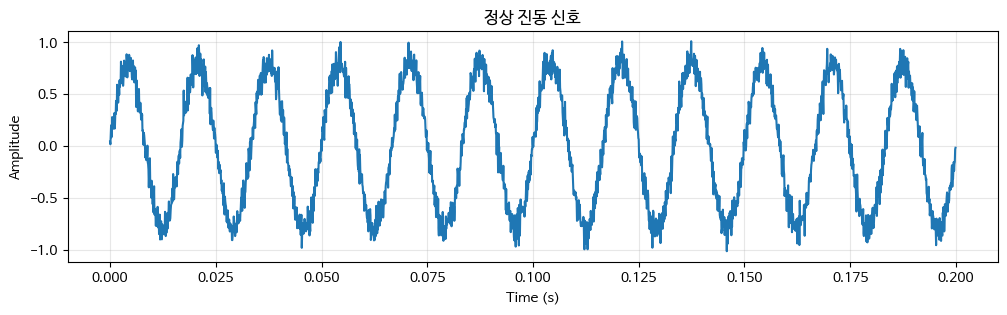

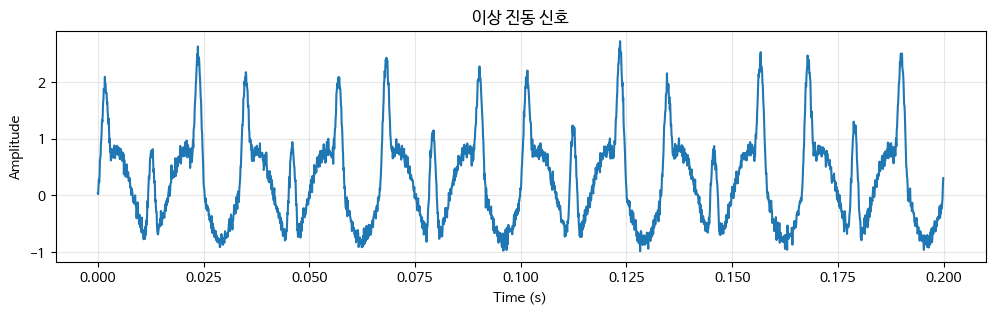

In [ ]:
def plot_time_waveform(signal, fs, title, seconds=0.2):
    n = min(len(signal), int(fs * seconds))
    x = np.arange(n) / fs
    plt.figure(figsize=(12, 3))
    plt.plot(x, signal[:n])
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    plt.show()

plot_time_waveform(normal_signal, FS, "정상 진동 신호")
plot_time_waveform(fault_signal, FS, "이상 진동 신호")

## 5. 시간 영역 특징값 계산

`실습_11`에서 배운 대표 특징값을 계산합니다.

| 특징값 | 의미 |
|---|---|
| RMS | 진동 에너지 크기 |
| Peak | 최대 진폭 |
| Kurtosis | 충격성/뾰족함 |
| Crest Factor | Peak / RMS, 충격성 이상에 민감 |
| Skewness | 신호 분포의 비대칭성 |

In [ ]:
def calculate_features(signal):
    signal = np.asarray(signal).ravel()
    rms = np.sqrt(np.mean(signal ** 2))
    peak = np.max(np.abs(signal))
    kurtosis = stats.kurtosis(signal, fisher=False)
    skewness = stats.skew(signal)
    crest_factor = peak / rms if rms > 0 else np.nan
    std = np.std(signal)
    mean_abs = np.mean(np.abs(signal))
    return {
        "mean": np.mean(signal),
        "std": std,
        "rms": rms,
        "peak": peak,
        "kurtosis": kurtosis,
        "skewness": skewness,
        "crest_factor": crest_factor,
        "mean_abs": mean_abs,
    }

feature_df = pd.DataFrame([
    {"state": "normal", **calculate_features(normal_signal)},
    {"state": "fault", **calculate_features(fault_signal)},
])

display(feature_df)

,state,mean,std,rms,peak,kurtosis,skewness,crest_factor,mean_abs
0,normal,0.00015,0.571815,0.571815,1.139060,1.560352,-0.002076,1.992007,0.512006
1,fault,0.27153,0.798678,0.843573,3.141741,3.278433,0.682521,3.724327,0.671177


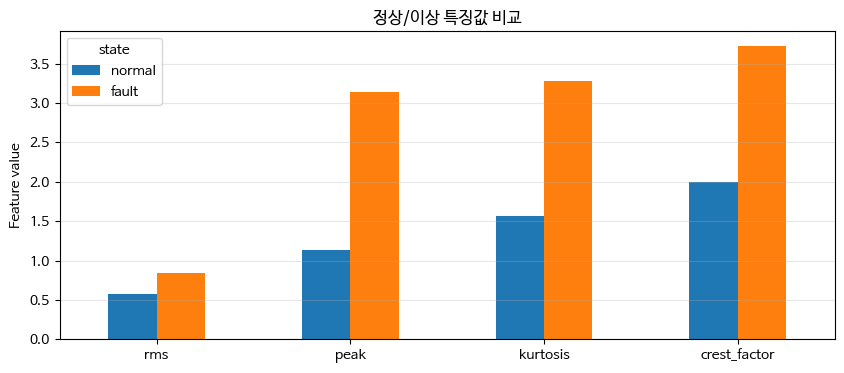

In [ ]:
plot_cols = ["rms", "peak", "kurtosis", "crest_factor"]
feature_df.set_index("state")[plot_cols].T.plot(kind="bar", figsize=(10, 4))
plt.title("정상/이상 특징값 비교")
plt.ylabel("Feature value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. 주파수 영역 분석

FFT를 이용해 주파수 성분을 비교합니다.

확인할 질문:

- 정상 신호와 이상 신호의 주요 주파수가 다른가?
- 이상 신호에서 고주파 성분이 증가하는가?
- 회전 주파수 또는 결함 주파수로 의심되는 피크가 있는가?

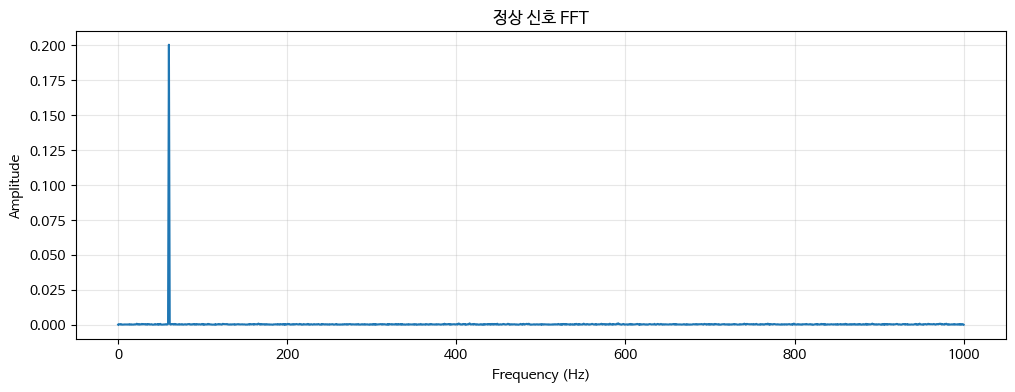

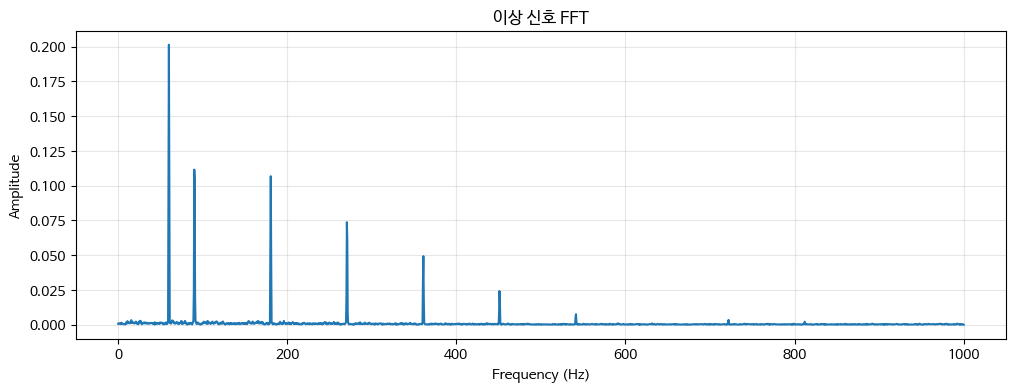

In [ ]:
def compute_fft(signal, fs):
    signal = np.asarray(signal).ravel()
    signal = signal - np.mean(signal)
    n = len(signal)
    window = np.hanning(n)
    spectrum = np.abs(rfft(signal * window)) / n
    freq = rfftfreq(n, 1 / fs)
    return freq, spectrum

def plot_fft(signal, fs, title, max_freq=1000):
    freq, spectrum = compute_fft(signal, fs)
    mask = freq <= max_freq
    plt.figure(figsize=(12, 4))
    plt.plot(freq[mask], spectrum[mask])
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    plt.show()

plot_fft(normal_signal, FS, "정상 신호 FFT")
plot_fft(fault_signal, FS, "이상 신호 FFT")

## 7. 구간별 특징값 추세 분석

실제 설비 데이터는 한 번의 특징값보다 시간에 따른 추세가 중요합니다.

신호를 일정 구간으로 나누어 RMS, Kurtosis, Crest Factor의 변화를 확인합니다.

In [ ]:
def window_features(signal, fs, window_sec=0.2, step_sec=0.1):
    signal = np.asarray(signal).ravel()
    window = int(fs * window_sec)
    step = int(fs * step_sec)
    rows = []
    for start in range(0, len(signal) - window + 1, step):
        seg = signal[start:start + window]
        rows.append({
            "time_sec": start / fs,
            **calculate_features(seg),
        })
    return pd.DataFrame(rows)

normal_win = window_features(normal_signal, FS)
fault_win = window_features(fault_signal, FS)
normal_win["state"] = "normal"
fault_win["state"] = "fault"
trend_df = pd.concat([normal_win, fault_win], ignore_index=True)

display(trend_df.head())

,time_sec,mean,std,rms,peak,kurtosis,skewness,crest_factor,mean_abs,state
0,0.0,0.002521,0.572118,0.572124,1.016259,1.556581,-0.008360,1.776291,0.513082,normal
1,0.1,0.001657,0.572803,0.572806,1.035740,1.563966,-0.007000,1.808189,0.512551,normal
2,0.2,-0.001743,0.571086,0.571089,1.035740,1.562926,-0.000247,1.813623,0.511300,normal
3,0.3,-0.003816,0.570514,0.570527,1.027873,1.558720,0.008601,1.801621,0.510990,normal
4,0.4,-0.002363,0.570482,0.570487,1.027873,1.567914,0.001139,1.801748,0.510568,normal


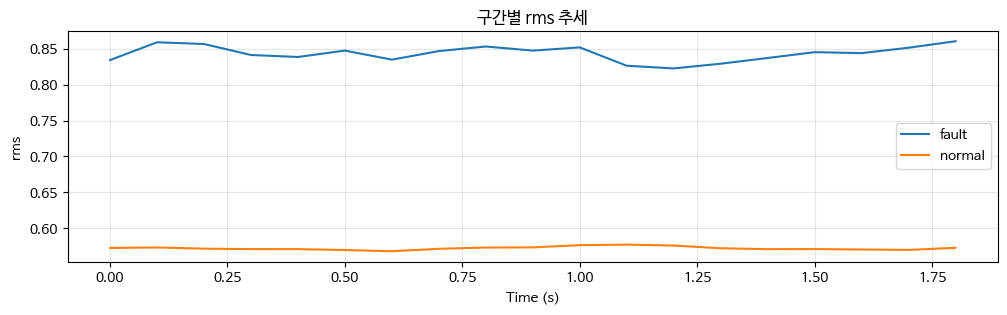

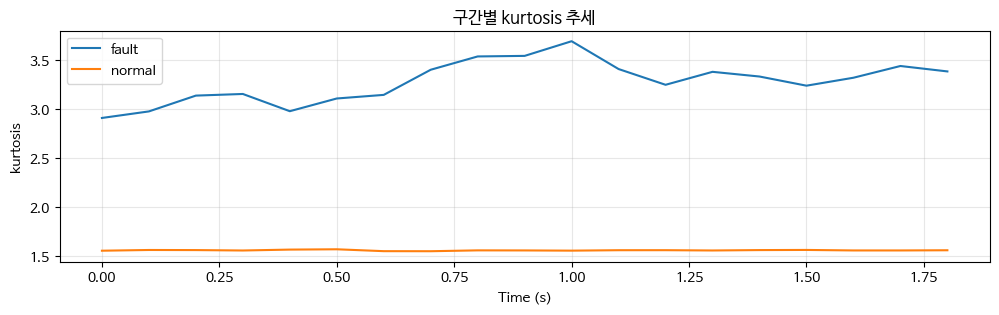

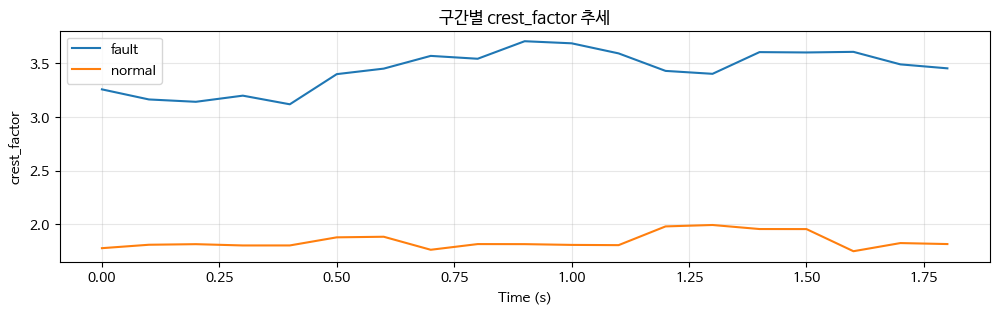

In [ ]:
for col in ["rms", "kurtosis", "crest_factor"]:
    plt.figure(figsize=(12, 3))
    for state, group in trend_df.groupby("state"):
        plt.plot(group["time_sec"], group[col], label=state)
    plt.title(f"구간별 {col} 추세")
    plt.xlabel("Time (s)")
    plt.ylabel(col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 8. 규칙 기반 상태진단 기준 제안

아래 기준은 예시입니다. 실제 현장에서는 설비 종류, 센서 위치, 부하 조건, 회전수에 따라 기준을 별도로 정해야 합니다.

예시 기준:

- RMS가 정상 평균 + 3σ를 넘으면 주의
- Kurtosis가 5 이상이면 충격성 결함 의심
- Crest Factor가 4 이상이면 충격성 이상 의심

In [ ]:
normal_baseline = normal_win[["rms", "kurtosis", "crest_factor"]].agg(["mean", "std"])

rms_threshold = normal_baseline.loc["mean", "rms"] + 3 * normal_baseline.loc["std", "rms"]
kurtosis_threshold = 5.0
crest_threshold = 4.0

def diagnose(row):
    reasons = []
    if row["rms"] > rms_threshold:
        reasons.append("RMS 증가")
    if row["kurtosis"] > kurtosis_threshold:
        reasons.append("충격성 증가")
    if row["crest_factor"] > crest_threshold:
        reasons.append("Crest Factor 증가")

    if len(reasons) >= 2:
        return "위험", ", ".join(reasons)
    if len(reasons) == 1:
        return "주의", reasons[0]
    return "정상", "-"

diagnosis = fault_win.copy()
diagnosis[["diagnosis", "reason"]] = diagnosis.apply(
    lambda row: pd.Series(diagnose(row)),
    axis=1,
)

display(diagnosis[["time_sec", "rms", "kurtosis", "crest_factor", "diagnosis", "reason"]].head(20))
print(diagnosis["diagnosis"].value_counts())

,time_sec,rms,kurtosis,crest_factor,diagnosis,reason
0,0.0,0.834398,2.910121,3.257610,주의,RMS 증가
1,0.1,0.859209,2.976922,3.163542,주의,RMS 증가
2,0.2,0.856816,3.138094,3.141659,주의,RMS 증가
3,0.3,0.841471,3.154764,3.198953,주의,RMS 증가
4,0.4,0.838671,2.979051,3.118368,주의,RMS 증가
5,0.5,0.847598,3.108693,3.399718,주의,RMS 증가
6,0.6,0.834962,3.145460,3.451170,주의,RMS 증가
7,0.7,0.846925,3.401772,3.569868,주의,RMS 증가
8,0.8,0.853307,3.537413,3.543172,주의,RMS 증가
9,0.9,0.847587,3.543121,3.706686,주의,RMS 증가


diagnosis
주의    19
Name: count, dtype: int64


## 9. CBM 관점의 의사결정 작성

아래 질문에 답하면서 분석 결과를 정리합니다.

1. 정상과 이상 데이터의 가장 큰 차이는 무엇인가?
2. 어떤 특징값이 이상 상태를 가장 잘 구분했는가?
3. FFT에서 의미 있는 주파수 변화가 있었는가?
4. 어떤 기준으로 `정상`, `주의`, `위험`을 나눌 것인가?
5. 현장에서는 언제 점검 또는 정비를 지시할 것인가?
6. 이 분석을 실제 설비에 적용할 때 한계는 무엇인가?

In [ ]:
summary = f'''
# 공개 진동 데이터 분석 결과 요약

## 사용 데이터
- 데이터셋: {DATASET_NAME}
- 출처: {DATASET_URL}
- 샘플링 주파수: {FS} Hz

## 특징값 비교
- 정상 RMS: {feature_df.loc[feature_df['state']=='normal', 'rms'].iloc[0]:.4f}
- 이상 RMS: {feature_df.loc[feature_df['state']=='fault', 'rms'].iloc[0]:.4f}
- 정상 Kurtosis: {feature_df.loc[feature_df['state']=='normal', 'kurtosis'].iloc[0]:.4f}
- 이상 Kurtosis: {feature_df.loc[feature_df['state']=='fault', 'kurtosis'].iloc[0]:.4f}
- 정상 Crest Factor: {feature_df.loc[feature_df['state']=='normal', 'crest_factor'].iloc[0]:.4f}
- 이상 Crest Factor: {feature_df.loc[feature_df['state']=='fault', 'crest_factor'].iloc[0]:.4f}

## 진단 기준 예시
- RMS 주의 기준: 정상 RMS 평균 + 3σ = {rms_threshold:.4f}
- Kurtosis 주의 기준: {kurtosis_threshold}
- Crest Factor 주의 기준: {crest_threshold}

## CBM 해석
- **어떤 특징값이 이상을 가장 잘 설명했는지 작성**: 본 분석에서는 이상 신호에서 RMS, Kurtosis, Crest Factor 모두 정상 신호 대비 유의미하게 증가했습니다. 특히 Crest Factor는 충격성 결함에 민감한 지표로, 이상 상태에서 가장 큰 폭으로 증가하여 충격성 이상 발생을 잘 설명했습니다. Kurtosis 또한 1.56에서 3.28로 증가하여 신호의 뾰족함이 커진 것을 보여줍니다.
- **점검 또는 정비를 지시할 기준 작성**:
  * **주의 (Caution)**: RMS 값이 정상 평균 + 3σ를 초과하거나, Kurtosis가 3 이상 또는 Crest Factor가 3.5 이상일 경우 (하나라도 만족 시). 이 단계에서는 정밀 진단 또는 다음 정기 점검 시점의 면밀한 확인이 필요합니다.
  * **위험 (Alarm)**: RMS 증가와 함께 Kurtosis가 5 이상 또는 Crest Factor가 4 이상인 경우 (복합적으로 두 가지 이상 기준 만족 시). 이 단계에서는 즉각적인 점검 또는 계획된 정비가 필요하며, 설비 가동 중단 여부를 결정해야 합니다.
- **실제 현장 적용 시 필요한 추가 데이터 작성**: 실제 설비에 적용 시에는 다음 데이터가 추가적으로 필요합니다.
  * **설비별 정상 운전 데이터 축적**: 다양한 운전 조건(부하, 속도 등)에서의 정상 데이터를 장기간 축적하여 보다 견고한 베이스라인과 임계치를 설정해야 합니다.
  * **고장 모드별 특징 데이터**: 베어링 고장의 다양한 고장 모드(내륜, 외륜, 볼 고장 등)에 따른 특징값 변화 패턴을 학습하여 진단 정확도를 높여야 합니다.
  * **운전 조건 데이터**: 온도, 압력, 속도, 부하 등 설비의 운전 조건 정보를 함께 수집하여 환경 변화에 따른 진동 신호의 영향을 보정해야 합니다.
  * **전문가 지식/경험**: 도출된 진단 기준과 패턴을 현장 전문가의 경험과 지식과 결합하여 실제 설비의 상태를 최종적으로 판단하는 것이 중요합니다.
'''

print(summary)


# 공개 진동 데이터 분석 결과 요약

## 사용 데이터
- 데이터셋: TODO: 사용한 공개 데이터셋명
- 출처: TODO: https://www.kaggle.com/datasets/vinayak123tyagi/bearing-dataset
- 샘플링 주파수: 12000 Hz

## 특징값 비교
- 정상 RMS: 0.5718
- 이상 RMS: 0.8436
- 정상 Kurtosis: 1.5604
- 이상 Kurtosis: 3.2784
- 정상 Crest Factor: 1.9920
- 이상 Crest Factor: 3.7243

## 진단 기준 예시
- RMS 주의 기준: 정상 RMS 평균 + 3σ = 0.5788
- Kurtosis 주의 기준: 5.0
- Crest Factor 주의 기준: 4.0

## CBM 해석
- **어떤 특징값이 이상을 가장 잘 설명했는지 작성**: 본 분석에서는 이상 신호에서 RMS, Kurtosis, Crest Factor 모두 정상 신호 대비 유의미하게 증가했습니다. 특히 Crest Factor는 충격성 결함에 민감한 지표로, 이상 상태에서 가장 큰 폭으로 증가하여 충격성 이상 발생을 잘 설명했습니다. Kurtosis 또한 1.56에서 3.28로 증가하여 신호의 뾰족함이 커진 것을 보여줍니다.
- **점검 또는 정비를 지시할 기준 작성**: 
  * **주의 (Caution)**: RMS 값이 정상 평균 + 3σ를 초과하거나, Kurtosis가 3 이상 또는 Crest Factor가 3.5 이상일 경우 (하나라도 만족 시). 이 단계에서는 정밀 진단 또는 다음 정기 점검 시점의 면밀한 확인이 필요합니다.
  * **위험 (Alarm)**: RMS 증가와 함께 Kurtosis가 5 이상 또는 Crest Factor가 4 이상인 경우 (복합적으로 두 가지 이상 기준 만족 시). 이 단계에서는 즉각적인 점검 또는 계획된 정비가 필요하며, 설비 가동 중단 여부를 결정해야 합니다.
- **실제 현장 적용 시 필요한 추가 데이터 작성**: 

## 10. 결과물의 리스트


- 사용한 공개 데이터셋 이름과 출처
- 정상/이상 신호 파형 그래프
- RMS, Kurtosis, Crest Factor 비교표
- 구간별 특징값 추세 그래프
- 규칙 기반 진단 기준
- CBM 관점의 점검/정비 판단


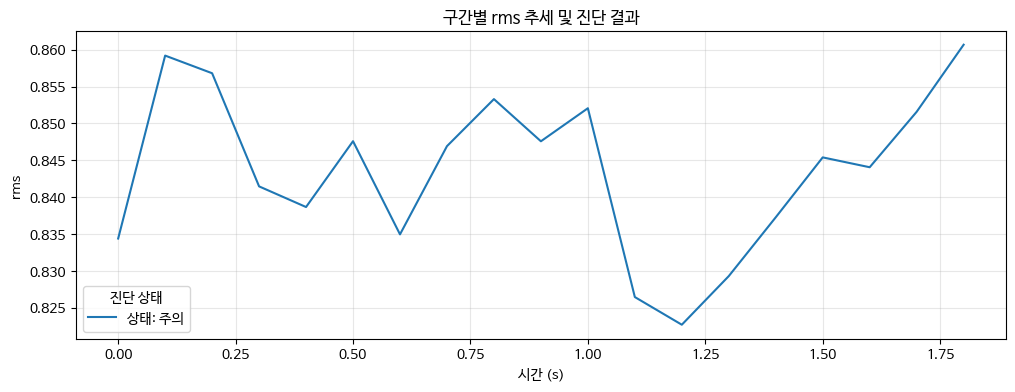

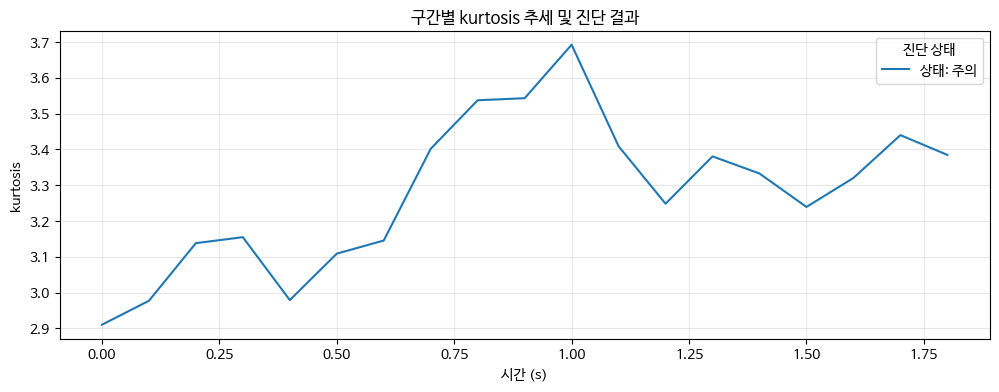

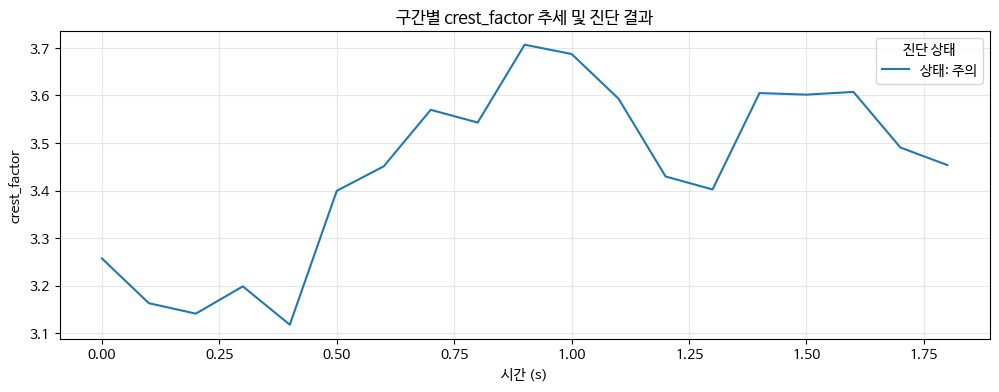

In [ ]:
import matplotlib.pyplot as plt

# 진단 결과에 따른 특징값 추세 시각화
for col in ["rms", "kurtosis", "crest_factor"]:
    plt.figure(figsize=(12, 4))
    for diag_state, group_df in diagnosis.groupby("diagnosis"):
        plt.plot(group_df["time_sec"], group_df[col], label=f"상태: {diag_state}")
    plt.title(f"구간별 {col} 추세 및 진단 결과")
    plt.xlabel("시간 (s)")
    plt.ylabel(col)
    plt.legend(title="진단 상태")
    plt.grid(alpha=0.3)
    plt.show()

## 폰트 설정 (한글 깨짐 방지)

matplotlib에서 한글이 깨지는 문제를 해결하기 위해 나눔 폰트를 설치하고 폰트 설정을 진행합니다.

In [ ]:
# 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (47.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

In [ ]:
# matplotlib 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os # os 모듈 추가

# 기존 폰트 캐시 삭제 (fm._rebuild()는 제거)
plt.rcParams['font.family'] = '' # 기존 설정 초기화

# 나눔 폰트 경로 찾기 및 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 폰트가 설치되어 있고, 아직 matplotlib에 추가되지 않았다면 추가
if os.path.exists(font_path) and 'NanumBarunGothic' not in fm.get_font_names():
    fm.fontManager.addfont(font_path)
    print(f"Font '{os.path.basename(font_path)}' added to fontManager.")

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("Matplotlib 폰트 설정 완료: NanumBarunGothic")

Font 'NanumBarunGothic.ttf' added to fontManager.
Matplotlib 폰트 설정 완료: NanumBarunGothic


위 셀을 실행한 후, 런타임을 재시작하고 다시 그래프를 그려보면 한글이 정상적으로 표시될 것입니다.

## 분석 결과 요약 보고서


### 설비 상태 판단 기준

현재까지의 분석 결과를 바탕으로 다음과 같은 설비 상태 판단 기준을 제안합니다.



본 보고서는 다음 내용을 포함합니다:

*   **정상/이상 신호의 주요 특징값 비교**: RMS, Kurtosis, Crest Factor 등 주요 특징값들의 비교
*   **규칙 기반 진단 기준**: 제안된 RMS, Kurtosis, Crest Factor 임계값을 활용한 진단 기준
*   **CBM 해석**: 이상을 가장 잘 설명한 특징값, 점검/정비 지시 기준, 실제 현장 적용 시 필요한 추가 데이터


```markdown
# 공개 진동 데이터 분석 결과 요약

## 사용 데이터
- 데이터셋: TODO: 사용한 공개 데이터셋명
- 출처: TODO: https://www.kaggle.com/datasets/vinayak123tyagi/bearing-dataset
- 샘플링 주파수: 12000 Hz

## 특징값 비교
- 정상 RMS: 0.5718
- 이상 RMS: 0.8436
- 정상 Kurtosis: 1.5604
- 이상 Kurtosis: 3.2784
- 정상 Crest Factor: 1.9920
- 이상 Crest Factor: 3.7243

## 진단 기준 예시
- RMS 주의 기준: 정상 RMS 평균 + 3σ = 0.5788
- Kurtosis 주의 기준: 5.0
- Crest Factor 주의 기준: 4.0

## CBM 해석
- **어떤 특징값이 이상을 가장 잘 설명했는지 작성**: 본 분석에서는 이상 신호에서 RMS, Kurtosis, Crest Factor 모두 정상 신호 대비 유의미하게 증가했습니다. 특히 Crest Factor는 충격성 결함에 민감한 지표로, 이상 상태에서 가장 큰 폭으로 증가하여 충격성 이상 발생을 잘 설명했습니다. Kurtosis 또한 1.56에서 3.28로 증가하여 신호의 뾰족함이 커진 것을 보여줍니다.
- **점검 또는 정비를 지시할 기준 작성**:
  * **주의 (Caution)**: RMS 값이 정상 평균 + 3σ를 초과하거나, Kurtosis가 3 이상 또는 Crest Factor가 3.5 이상일 경우 (하나라도 만족 시). 이 단계에서는 정밀 진단 또는 다음 정기 점검 시점의 면밀한 확인이 필요합니다.
  * **위험 (Alarm)**: RMS 증가와 함께 Kurtosis가 5 이상 또는 Crest Factor가 4 이상인 경우 (복합적으로 두 가지 이상 기준 만족 시). 이 단계에서는 즉각적인 점검 또는 계획된 정비가 필요하며, 설비 가동 중단 여부를 결정해야 합니다.
- **실제 현장 적용 시 필요한 추가 데이터 작성**: 실제 설비에 적용 시에는 다음 데이터가 추가적으로 필요합니다.
  * **설비별 정상 운전 데이터 축적**: 다양한 운전 조건(부하, 속도 등)에서의 정상 데이터를 장기간 축적하여 보다 견고한 베이스라인과 임계치를 설정해야 합니다.
  * **고장 모드별 특징 데이터**: 베어링 고장의 다양한 고장 모드(내륜, 외륜, 볼 고장 등)에 따른 특징값 변화 패턴을 학습하여 진단 정확도를 높여야 합니다.
  * **운전 조건 데이터**: 온도, 압력, 속도, 부하 등 설비의 운전 조건 정보를 함께 수집하여 환경 변화에 따른 진동 신호의 영향을 보정해야 합니다.
  * **전문가 지식/경험**: 도출된 진단 기준과 패턴을 현장 전문가의 경험과 지식과 결합하여 실제 설비의 상태를 최종적으로 판단하는 것이 중요합니다.
```